# Explore the Replica data

Frames, depth and object masks from vMAP, labels from OpenLex3D (see `scripts/download_data.sh`).
The loaders live in `src/utils/replica.py`.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import rerun as rr

from utils import replica

SCENE, SEQ = "room_0", "00"  # replica.SCENES, sequence "00" or "01"
objects = replica.load_objects(SCENE)
poses = replica.load_poses(SCENE, SEQ)

# A fixed random colour per object ID and black for 0 (no object), so neighbouring IDs look different
lut = np.random.default_rng(0).uniform(0.2, 1, (max(objects) + 1, 3))
lut[0] = 0

## One frame

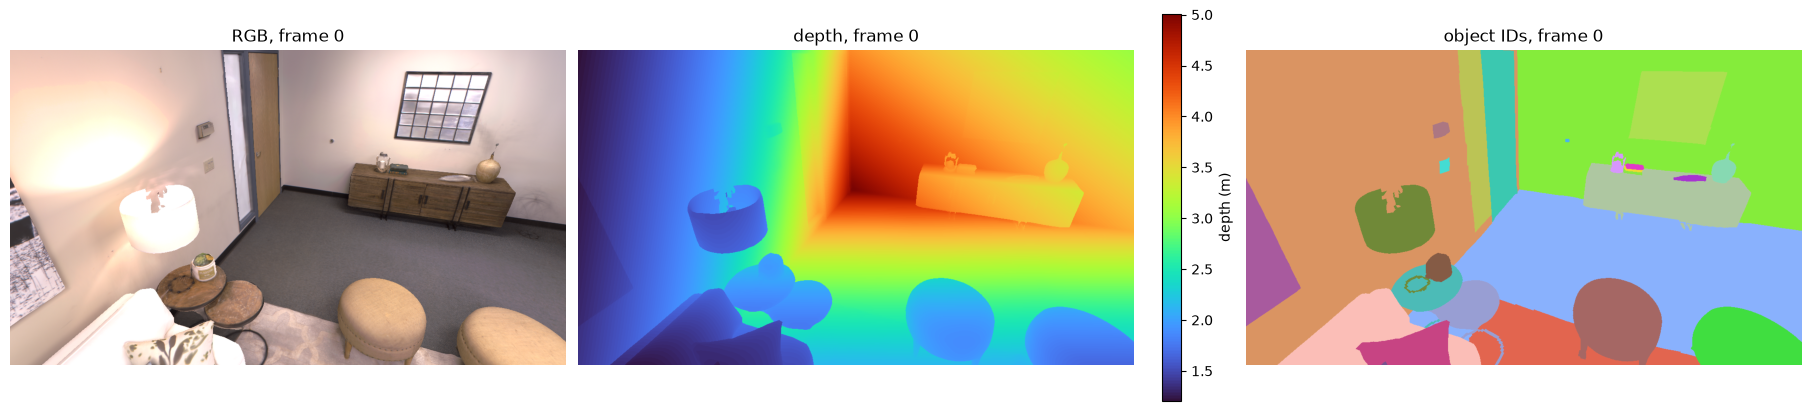

In [3]:
i = 0
rgb, depth, ids = replica.load_frame(SCENE, SEQ, i)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), layout="constrained")
axes[0].imshow(rgb)
im = axes[1].imshow(np.ma.masked_equal(depth, 0), cmap="turbo")
fig.colorbar(im, ax=axes[1], label="depth (m)")
axes[2].imshow(lut[ids])
for ax, title in zip(axes, ["RGB", "depth", "object IDs"], strict=True):
    ax.set_title(f"{title}, frame {i}")
    ax.axis("off")

## Frames along the sequence

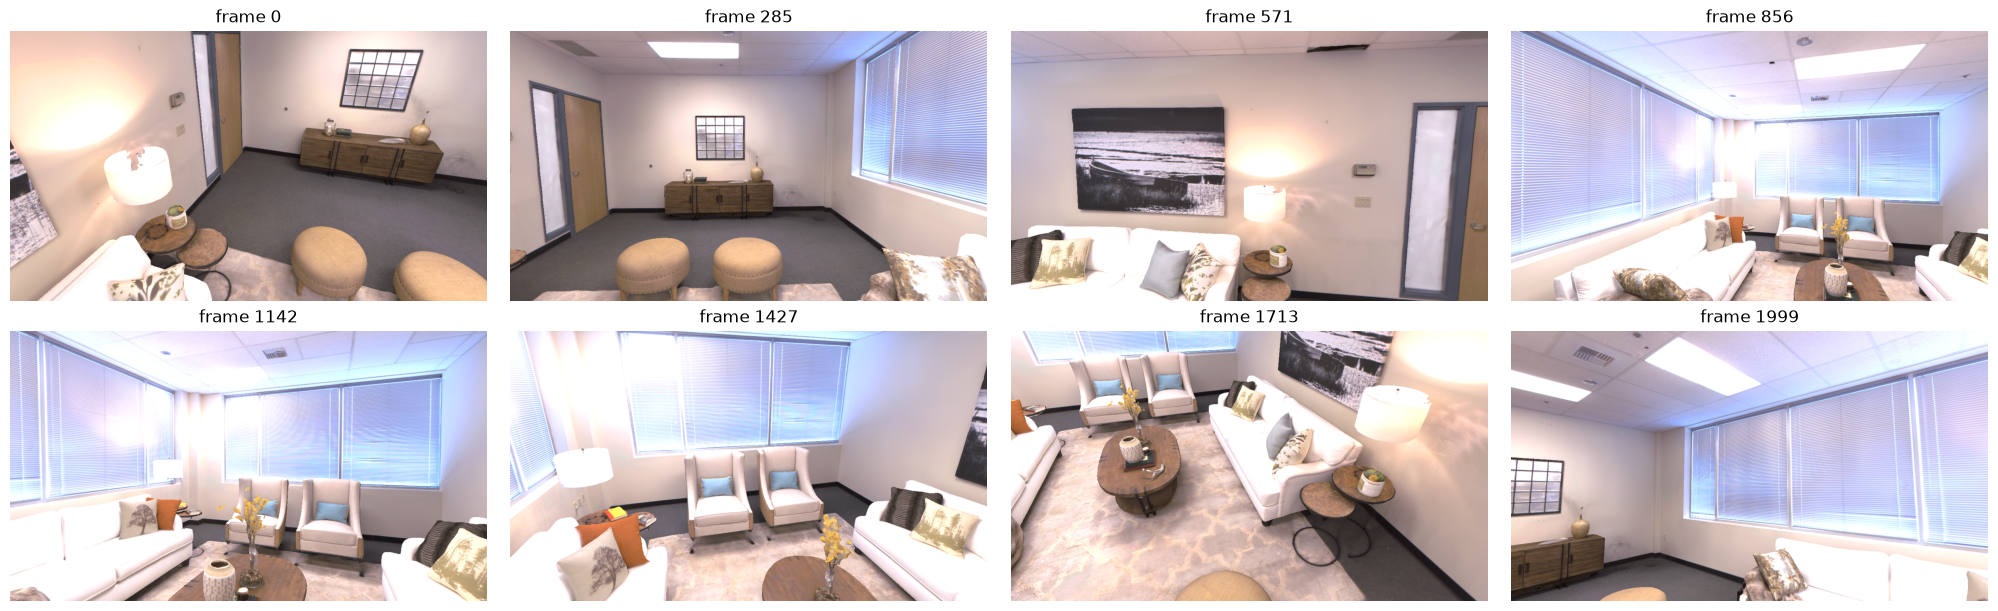

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(20, 6), layout="constrained")
for ax, i in zip(axes.flat, np.linspace(0, replica.N_FRAMES - 1, axes.size, dtype=int), strict=True):
    ax.imshow(replica.load_frame(SCENE, SEQ, i)[0])
    ax.set_title(f"frame {i}")
    ax.axis("off")

## Camera path from above

Arrows show the viewing direction (the camera z axis) every 100 frames.

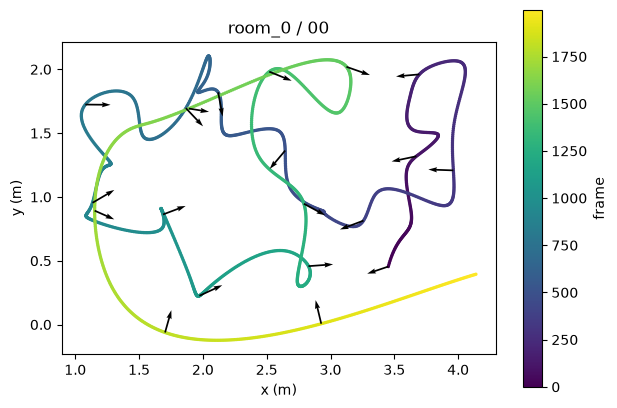

In [5]:
xy = poses[:, :2, 3]
fig, ax = plt.subplots(figsize=(7, 7))
points = ax.scatter(*xy.T, c=np.arange(len(xy)), s=2)
fig.colorbar(points, ax=ax, label="frame", shrink=0.7)
ax.quiver(*xy[::100].T, *poses[::100, :2, 2].T, angles="xy", width=0.004)
ax.set(aspect="equal", xlabel="x (m)", ylabel="y (m)", title=f"{SCENE} / {SEQ}");

## One object's labels

The largest object in frame `i` with OpenLex3D labels for visually similar things, and all its labels.
`clutter` lists nearby objects by ID, shown here with their Replica class.

  synonyms: carpet, carpet floor, carpeted floor, floor, flooring, ground
   vis_sim: area rug, rug
depictions: 
   clutter: cabinet (2), lamp (6), table (7), sofa (9), table (10), table (11), table (27), wall (33), door (36), stool (39), stool (41), pillar (46), wall (48), wall (57), rug (60), chair (73), chair (74), basket (75), sofa (77), pillar (84), blanket (86), wall (89), table (93)

All objects in the frame: book, cabinet, candle, cushion, door, floor, lamp, picture, plate, rug, sofa, stool, switch, table, undefined, vase, wall, window


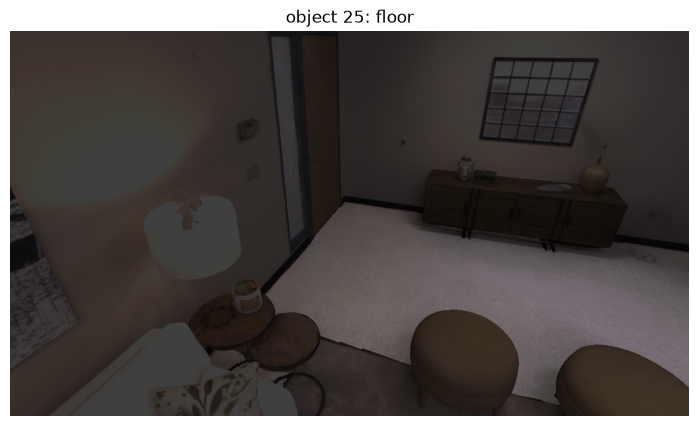

In [6]:
i = 0
rgb, _, ids = replica.load_frame(SCENE, SEQ, i)
visible, pixels = np.unique(ids[ids > 0], return_counts=True)
obj = next(objects[j] for j in visible[np.argsort(-pixels)] if objects[j].labels.get("vis_sim"))

mask = ids == obj.id
plt.figure(figsize=(9, 5))
plt.imshow(np.where(mask[..., None], rgb, rgb // 4))
plt.title(f"object {obj.id}: {obj.class_name}")
plt.axis("off")
for category, names in obj.labels.items():
    if category == "clutter":
        names = [f"{objects[int(j)].class_name} ({j})" if int(j) in objects else j for j in names]
    print(f"{category:>10}: {', '.join(names)}")
print("\nAll objects in the frame:", ", ".join(sorted({objects[j].class_name for j in visible})))

## 3D in Rerun

Every 20th frame: RGB, depth as a point cloud, object masks (hover for the Replica class and OpenLex3D synonyms)
and the camera path. Drag the `frame` timeline to move the camera. A smaller step sends more data through Jupyter.

In [ ]:
rr.init(f"replica_{SCENE}_{SEQ}")
rr.notebook_show(height=700)
replica.log_to_rerun(SCENE, SEQ, step=20)

## SAM 3 short clip

Run this section on the GPU machine with the `EAI project` kernel. First request access to [facebook/sam3](https://huggingface.co/facebook/sam3) and log in once from a terminal with `uv run --no-sync hf auth login`.
The first run downloads the weights. This uses SAM 3 video tracking with one text prompt; it only finds objects matching that prompt.

Choose a short contiguous clip below. Predictions are cached under `outputs/`; set `RUN_SAM = False` to reopen that cache.
The inspection cell is independent of inference: scrub the frame timeline to compare RGB with predicted masks and track IDs.
These are SAM IDs within this clip, not ground-truth instance IDs or persistent graph IDs.

In [1]:
from models.sam3 import segment_clip
from utils import replica

SCENE, SEQ = "room_0", "00"
START, N_FRAMES, STEP = 0, 60, 1
PROMPT = "lamp"
RUN_SAM = True
OUTPUT = replica.REPO_ROOT / "outputs" / "sam3_preview"

frame_ids = range(START, START + N_FRAMES * STEP, STEP)
frame_paths = [replica.sequence_dir(SCENE, SEQ) / "rgb" / f"rgb_{i}.png" for i in frame_ids]
if RUN_SAM:
    segment_clip(frame_paths, PROMPT, OUTPUT)

/home/johan/courses/eai_project/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Loading facebook/sam3; tracking 'lamp' over 60 frames.


[transformers] `memory_attention_rope_theta` is deprecated and will be removed in v5.0. Use `rope_parameters['rope_theta']` instead.


Loading weights:   0%|          | 0/1797 [00:00<?, ?it/s]

propagate in video:   0%|          | 0/60 [00:00<?, ?it/s]

[transformers] kernels library is not installed. NMS post-processing, hole filling, and sprinkle removal will be skipped. Install it with `pip install kernels` for better mask quality.


Saved predictions to /home/johan/courses/eai_project/outputs/sam3_preview


In [ ]:
import json
from pathlib import Path

import numpy as np
import rerun as rr
import rerun.blueprint as rrb
from PIL import Image

manifest = json.loads((OUTPUT / "manifest.json").read_text())
if not manifest["complete"]:
    raise RuntimeError("The SAM run did not finish. Rerun the inference cell.")

rr.init("sam3_preview")
rr.notebook_show(height=650)
rr.send_blueprint(
    rrb.Blueprint(
        rrb.Horizontal(
            rrb.Spatial2DView(origin="clip", contents="clip/rgb", name="RGB"),
            rrb.Spatial2DView(origin="clip", contents="clip/**", name=f"SAM 3: {manifest['prompt']}"),
        )
    )
)

all_ids = set()
for clip_index, source_path in enumerate(manifest["frames"]):
    with Image.open(source_path) as image:
        rgb = np.array(image.convert("RGB"))
    with np.load(OUTPUT / f"{clip_index:05d}.npz", allow_pickle=False) as result:
        masks, ids = result["masks"], result["object_ids"]
        scores, boxes = result["scores"], result["boxes"]
    all_ids.update(ids.tolist())
    # Reserve 0 for background; SAM track IDs can start at 0.
    segments = np.zeros(rgb.shape[:2], dtype=np.uint32)
    for index in np.argsort(scores):
        segments[masks[index]] = int(ids[index]) + 1
    rr.set_time("frame", sequence=int(Path(source_path).stem.rsplit("_", 1)[-1]))
    rr.log(
        "clip",
        rr.AnnotationContext(
            [
                rr.AnnotationInfo(id=0, label="background", color=(0, 0, 0, 0)),
                *[rr.AnnotationInfo(id=int(i) + 1, label=f"track {i}") for i in ids],
            ]
        ),
    )
    rr.log("clip/rgb", rr.Image(rgb).compress(jpeg_quality=90))
    rr.log("clip/masks", rr.SegmentationImage(segments, opacity=0.45))
    rr.log(
        "clip/boxes",
        rr.Boxes2D(
            array=boxes,
            array_format=rr.Box2DFormat.XYXY,
            class_ids=ids + 1,
            labels=[f"track {i}: {score:.2f}" for i, score in zip(ids, scores, strict=True)],
            show_labels=True,
        ),
    )

print(f"{len(manifest['frames'])} frames; {len(all_ids)} SAM tracks for {manifest['prompt']!r}.")